In [1]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import pytometry as pt
import rapids_singlecell as rsc
import scanpy as sc


# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


/home/icb/lorenzo.consoli/miniconda3/envs/rapids_singlecell/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

In [3]:
# optionally subsample the data
def get_adata_copy():
    SUBSAMPLE_SIZE = 1e-3
    adata_copy = adata.copy()
    sc.pp.subsample(adata_copy, SUBSAMPLE_SIZE)
    return adata_copy


In [4]:
channel2cofactor = {
    'CD49f':3_000,
    'CD235a':3_000,
    'CD34':5_000,
    'CD19':2_500,
    'CD49c':5_000,
    'CD41a':2_500,
    'CD117':3_000,
    'CD38':2_500,
    'HLADR':3_000,
    'EPCR':5_000,
    'CD135':3_000,
    'CD56':1_000,
    'CD15':3_000,
    'CD123':3_000,
    'CD45':1_500,
    'CD90':3_000,
    'CD45RA':10_000,
    'CD10':5_000,
    'CD14':3_000,
    'CD7': 500,
    'CD16': 750,
}


In [5]:
X_channels = adata.X
cofactors = np.zeros((1, X_channels.shape[1]))
for channel, cofactor in channel2cofactor.items():
    idx = adata.var_names.tolist().index(channel)
    cofactors[0, idx] = cofactor
X_channels = np.arcsinh(X_channels / cofactors)
layer_key = "X_arcsinh"
adata.layers[layer_key] = X_channels


In [14]:
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]',
    'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]',
    'ldl_[ng/ml]', 'il3_[ng/ml]', 'o2_[%]', "experiment_id", "replicate", "well_id", 
    "plate", "date", "days_of_culture", "source_cell_phenotype"
]

adata_copy = get_adata_copy()
rsc.pp.pca(adata_copy, layer=layer_key)
rsc.pp.neighbors(adata_copy)
rsc.tl.umap(adata_copy)
rsc.tl.tsne(adata_copy)
rsc.tl.louvain(adata_copy)
rsc.tl.leiden(adata_copy, resolution=0.7)
adata_copy


AnnData object with n_obs × n_vars = 93278 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'louvain', 'leiden'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta', 'pca', 'neighbors', 'umap', 'gm-csf_[ng/ml]_colors', 'experiment_id_colors', 'well_id_colors', 'date_colors', 'source_cell_phenotype_colors', 'louvain', 'leiden', 'louvain_colors', 'leiden

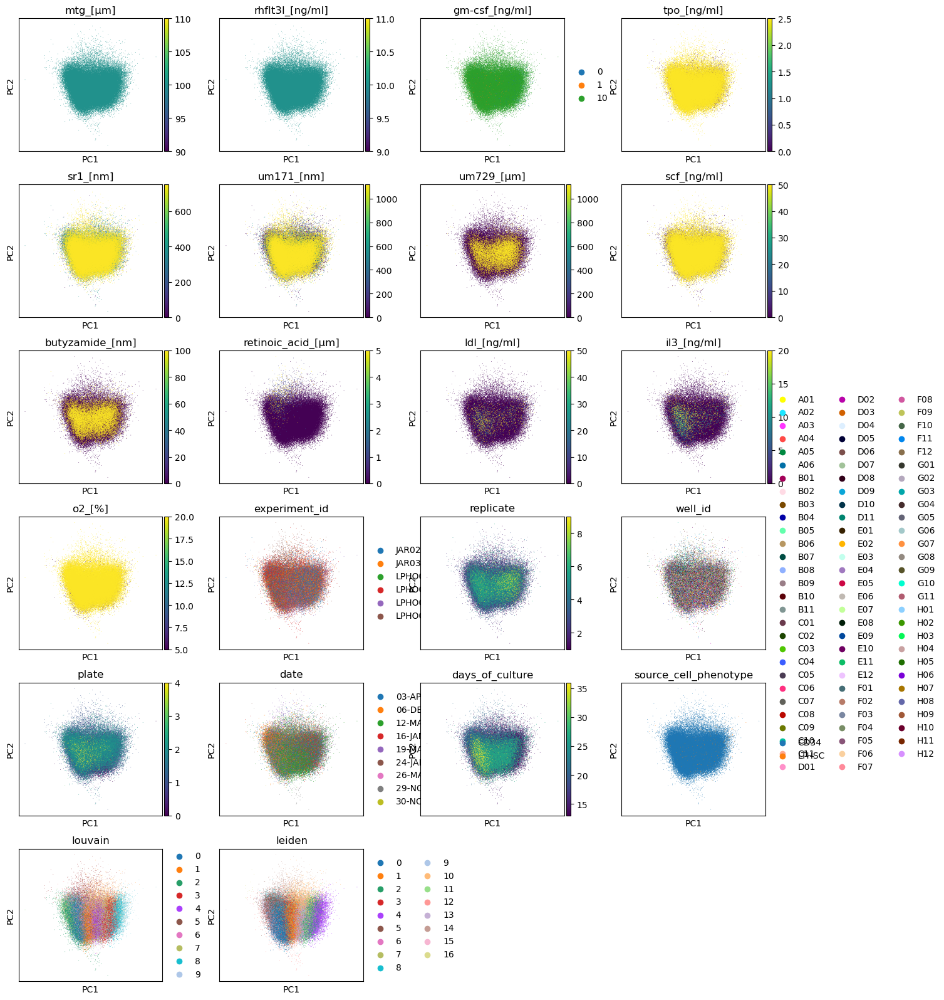

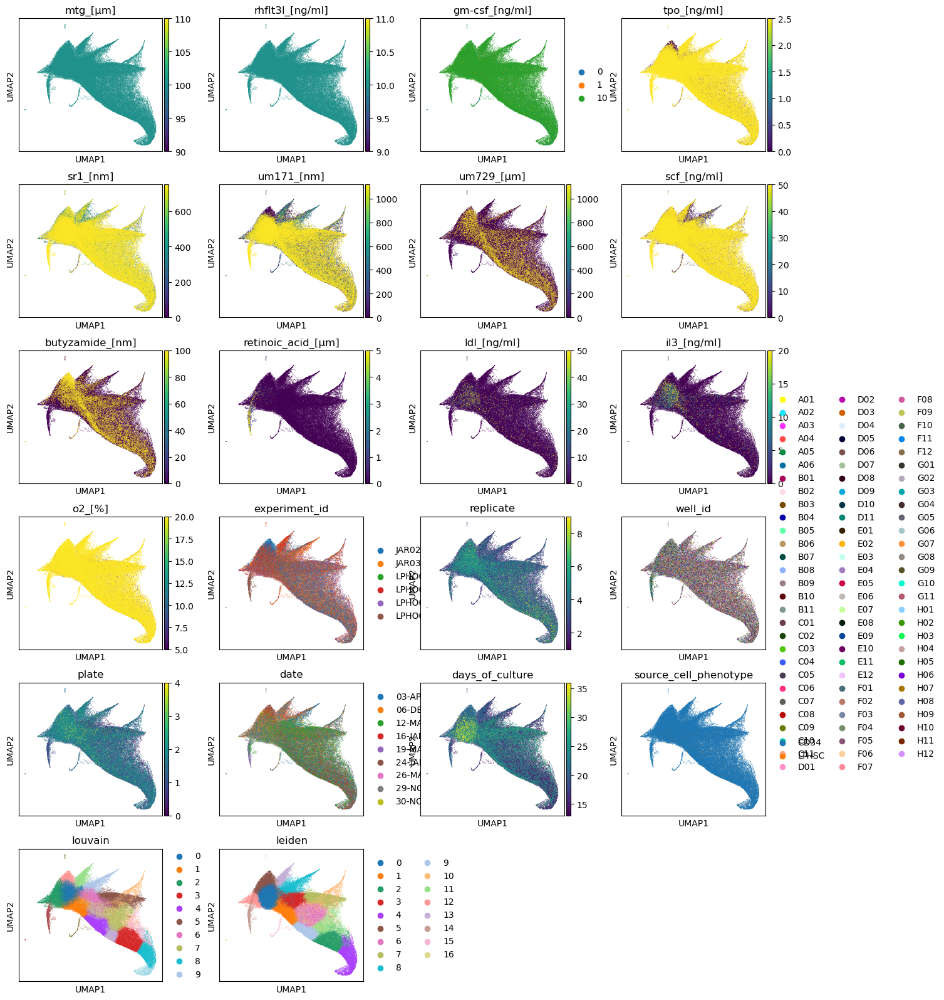

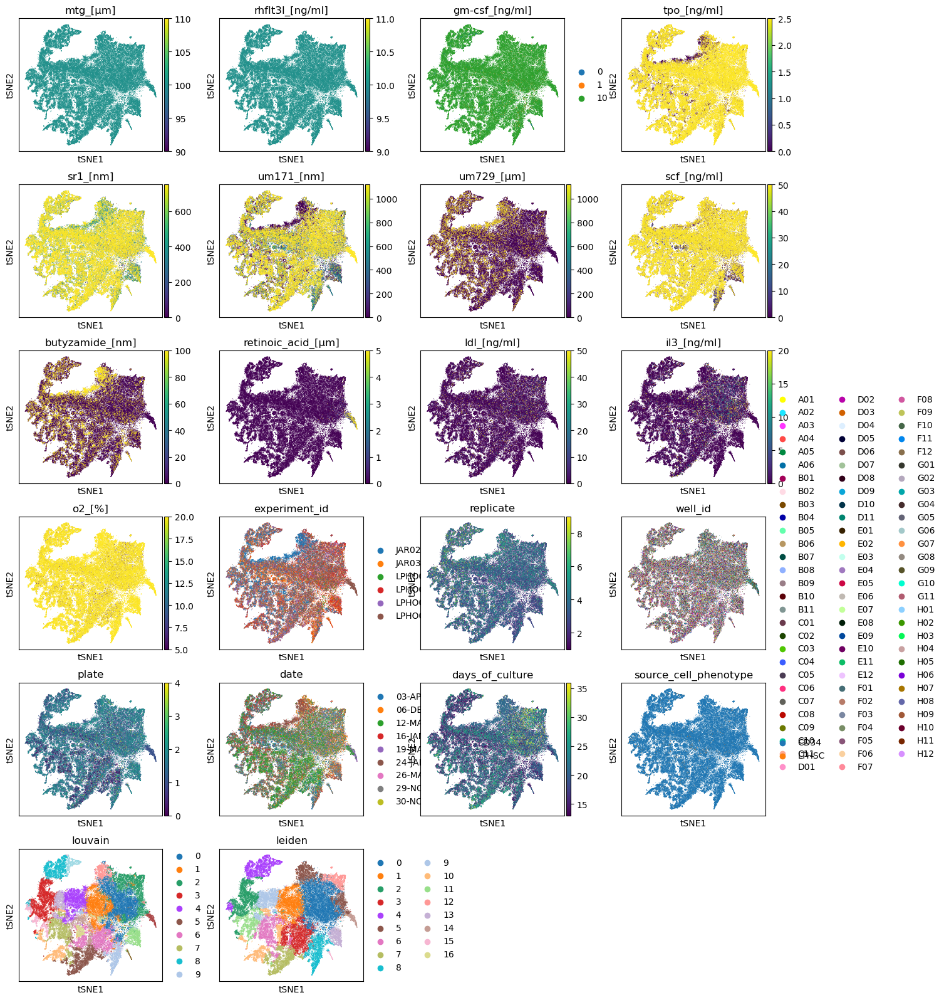

In [18]:
sc.pl.embedding(adata_copy, color=EXPERIMENTAL_COLUMNS + ["louvain", "leiden"], basis="pca")
sc.pl.embedding(adata_copy, color=EXPERIMENTAL_COLUMNS + ["louvain", "leiden"], basis="umap")
sc.pl.embedding(adata_copy, color=EXPERIMENTAL_COLUMNS + ["louvain", "leiden"], basis="tsne")


In [19]:
adata_copy = get_adata_copy()
pt.tl.normalize_logicle(adata_copy, **{'t': 1048576, 'a': 0.1, 'w': 1.75}, inplace=True)
rsc.pp.pca(adata_copy)
rsc.pp.neighbors(adata_copy)
rsc.tl.umap(adata_copy)
rsc.tl.tsne(adata_copy)
rsc.tl.louvain(adata_copy)
rsc.tl.leiden(adata_copy, resolution=0.7)
adata_copy


[2025-07-25 15:40:00.703] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization
[2025-07-25 15:40:06.631] [CUML] [debug] n_neighbors=15
[2025-07-25 15:40:06.652] [CUML] [debug] Calling knn graph run
[2025-07-25 15:40:06.652] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-07-25 15:40:06.774] [CUML] [debug] Done. Calling remove zeros
[2025-07-25 15:40:10.388] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


AnnData object with n_obs × n_vars = 93278 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'louvain', 'leiden'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta', 'pca', 'neighbors', 'umap', 'tsne', 'louvain', 'leiden'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    layers: 'X_arcsinh'
    obsp: 'distances', 'connectivities'

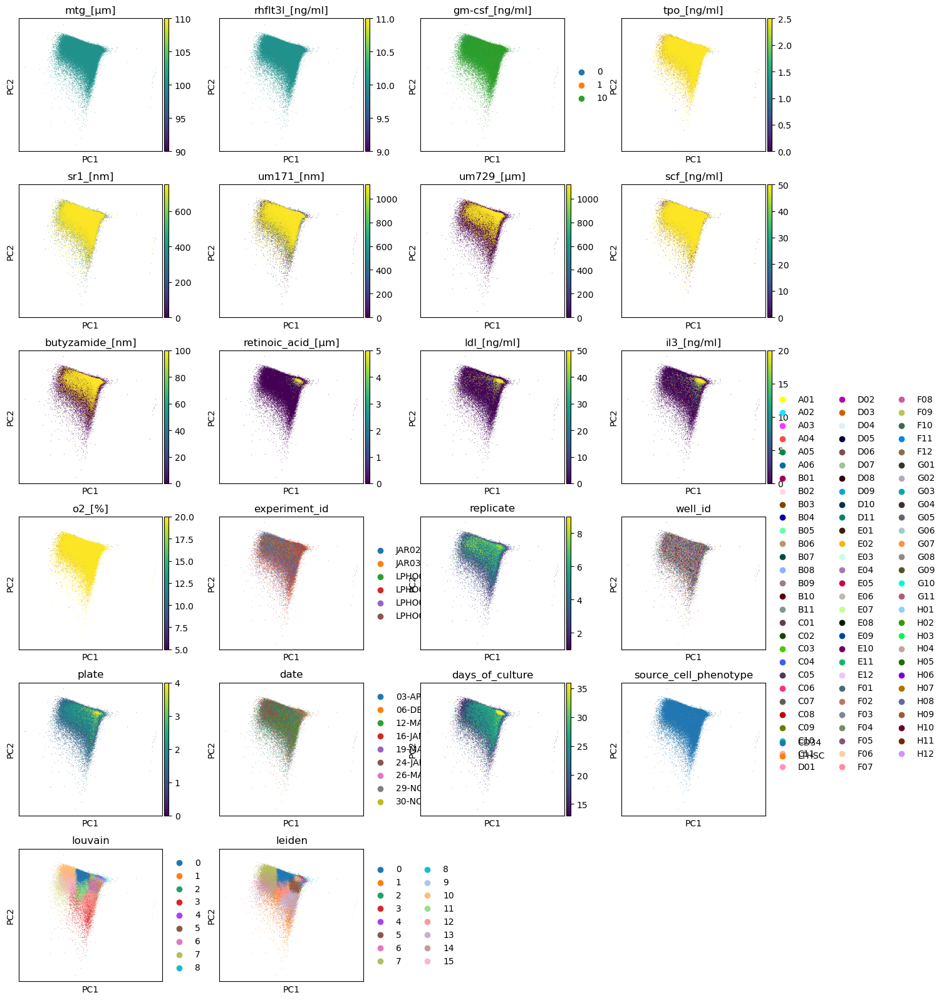

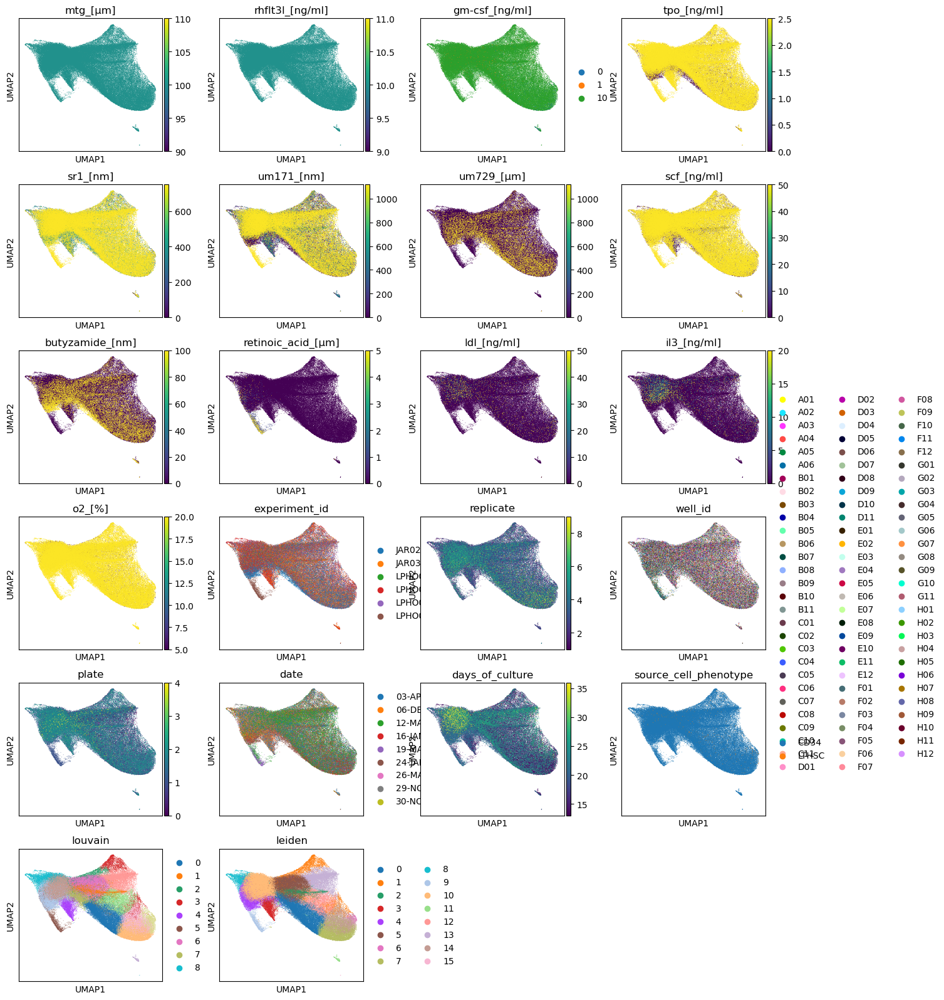

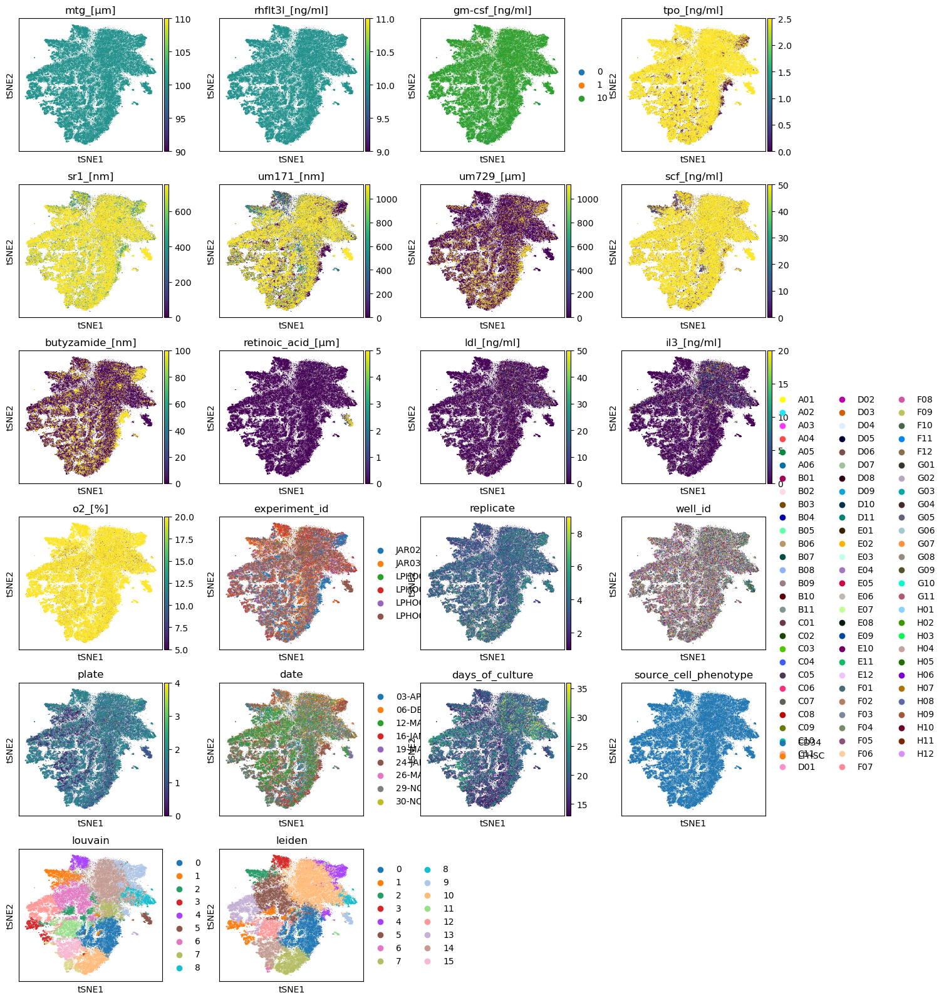

In [20]:
sc.pl.embedding(adata_copy, color=EXPERIMENTAL_COLUMNS + ["louvain", "leiden"], basis="pca")
sc.pl.embedding(adata_copy, color=EXPERIMENTAL_COLUMNS + ["louvain", "leiden"], basis="umap")
sc.pl.embedding(adata_copy, color=EXPERIMENTAL_COLUMNS + ["louvain", "leiden"], basis="tsne")
